# **RFscorer Tutorial: Advanced (English): Time-Series Rolling Training (fit_rolling)**

This notebook explains **time-series rolling training** with `fit_rolling()`, following a workflow that assumes real-world operation.

Specifically, you will learn the following workflow.

1. Assume an **operational scenario** and split the data into training data / test data chronologically
2. Run **rolling aggregation** with `fit_rolling()` to estimate the empirical product-choice probability stably
3. Build and visualize all **9 models**
4. Generate recommendations on the test data and compare accuracy across all models

In contrast to the single-snapshot training (`fit()`) of the Practical tutorial (`tutorial_practical_en.ipynb`), this notebook uses `fit_rolling()`, which aggregates while shifting the reference date one day into the past at a time.

When running on Google Colab, the following setup is required.
- Install `rfscorer`
```python
!pip install rfscorer
```
- Mount Google Drive (when reading/writing files)
```python
from google.colab import drive
drive.mount("/content/drive")
```

---
## **Data Loading and Preprocessing**
Load a public dataset hosted on GitHub via its URL, then perform a **time-based split that assumes real-world operation**.

- Use data up to the reference date `target_date` (the operational "today") as training data, and the next day `gt_date` as the prediction target (the future)
- The training data is split internally into observation and ground truth periods by `fit_rolling()` later, so here we only slice it by period
- The test data is split with `split_by_date()` into observation data and ground truth data for evaluation

In [1]:
import pandas as pd

from rfscorer import RecencyFrequencyScorer, split_by_date

In [2]:
# `access_log.csv` is from ohmsha/PyOptBook (MIT License)
# https://github.com/ohmsha/PyOptBook/tree/main/7.recommendation
url = "https://raw.githubusercontent.com/ohmsha/PyOptBook/main/7.recommendation/access_log.csv"
df = pd.read_csv(url)
df.columns = ["user", "item", "datetime"]

print("record num:", len(df))
print("user num:", len(df.user.unique()))
print("item num:", len(df.item.unique()))
print("datetime num:", len(sorted(df.datetime.unique())))
print("datetime:", sorted(df.datetime.unique()))
df.head()

record num: 325908
user num: 31443
item num: 87611
datetime num: 8
datetime: ['2015-07-01', '2015-07-02', '2015-07-03', '2015-07-04', '2015-07-05', '2015-07-06', '2015-07-07', '2015-07-08']


,user,item,datetime
0,4,205587,2015-07-04
1,4,748683,2015-07-04
2,4,790055,2015-07-04
3,4,790055,2015-07-04
4,4,764638,2015-07-04


In [3]:
# Assume real-world operation: with data available up to 2015-07-07, predict 2015-07-08 (= decide the recommended items)
# e.g., at 2015-07-08 01:00, fetch data up to 2015-07-08 00:00 and build the model,
# then register the recommendations to the DB by 2015-07-08 07:00 and deliver them

target_date = "2015-07-07"
gt_date = "2015-07-08"
df_train = df[df.datetime <= target_date]  # data up to 2015-07-07
df_test = df[df.datetime <= gt_date]  # 2015-07-08 is treated as the future
df_test_obs, df_test_gt = split_by_date(df_test, target_date, observation_days=4, gt_days=1)

print("train record num:", len(df_train), "/ user num:", len(df_train.user.unique()))
print("test  record num: ", len(df_test), "/ user num: ", len(df_test.user.unique()))

train record num: 285975 / user num: 28605
test  record num:  325908 / user num:  31443


---
## **Rolling Training (fit_rolling)**

`fit_rolling()` performs **rolling aggregation**. Shifting the reference date (split point) one day into the past at a time, it slices the observation and ground truth periods at multiple reference dates and accumulates the counts. This increases the sample size so the empirical product-choice probability stabilizes, and it smooths out reference-date-specific bias.

- `observation_days` / `gt_days`: the length of the observation / ground truth period for each roll
- `roll_days`: the number of reference dates to aggregate (shifting one day into the past at a time). For daily data with a sufficiently long period, a multiple of 7 is recommended to balance out day-of-week effects
- `recency_limit` / `frequency_limit`: upper limits on recency / frequency (clamped based on the pooled distribution)

Passing the same behavior history as both `df_obs` and `df_gt` treats "revisits" as the target event (observation and ground truth are the same behavior history).

In [4]:
scorer = RecencyFrequencyScorer()

# === fit_rolling ===
# *: observation_days = 4
# @: gt_days = 1
#                    target_date
#                      ^
# 2015-07-01 2 3 4 5 6 7 8
# test           * * * * @
# train1       * * * * @
# train2     * * * * @
# train3   * * * * @
scorer.fit_rolling(
    df_train,  # df_obs (behavior history as the observation data)
    df_train,  # df_gt (same behavior history as the ground truth; target event = "revisit")
    observation_days=4,
    gt_days=1,
    roll_days=3,
    # end_date=None,
    recency_limit=4,
    frequency_limit=15,
    time_col=None,
)
scorer.show()  # display data statistics, correlation coefficients, and the empirical product-choice probability table

=== RecencyFrequencyScorer ===

── Data ──────────────────────────────────────────────
  dataset          : obs 252045 rows,  gt 107173 events  (users: 26030,  items: 74811)
  observation      : 2015-07-01 → 2015-07-06
  ground truth     : 2015-07-05 → 2015-07-07
  rolling          : roll_days=3,  obs_window=4,  gt_window=1
  pooled rows      : 623034  (obs: 515861,  gt: 107173)
  user×item pairs  : 372709 → 372550  (before → after limits; pooled over rolls)
  target events    : 4299 → 4273  (before → after limits; pooled over rolls)

── Model ─────────────────────────────────────────────
  recency_limit    : 4
  frequency_limit  : 15

── Correlation ───────────────────────────────────────
  [expected: recency ρ < 0  (more recent → higher prob),
             frequency ρ > 0  (more frequent → higher prob)]
  recency  ρ       : -1.0000  (p=0.0000,  n=4,  weighted ρ: -1.0000)
  frequency ρ      :  0.8607  (p=0.0000,  n=15,  weighted ρ:  0.9852)

  Slice ρ by r  [corr(f, P(r,f)),  expected

---
## **Model Building and Visualization**

Based on the empirical product-choice probability estimated by the rolling aggregation (`fit_rolling`), build and visualize 6 optimization models.

| Model | Type | Constraints |
|--------|------|------|
| `emp` | Empirical (2D) | none |
| `er` / `ef` | Empirical (1D) | none |
| `mr` | Optimization (1D) | Recency monotonicity + convexity |
| `mf` | Optimization (1D) | Frequency monotonicity + concavity |
| `mono` | Optimization (2D) | monotonicity only |
| `mrc` | Optimization (2D) | monotonicity + Recency convexity |
| `mfc` | Optimization (2D) | monotonicity + Frequency concavity |
| `mcc` | Optimization (2D) | monotonicity + Recency convexity + Frequency concavity |

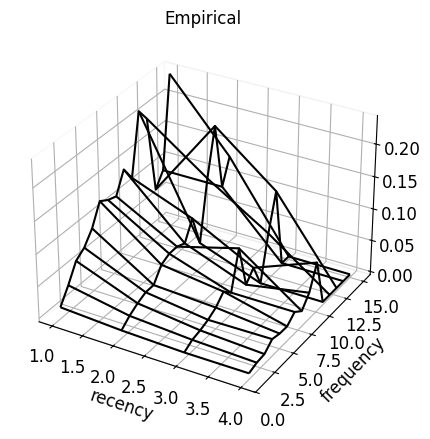

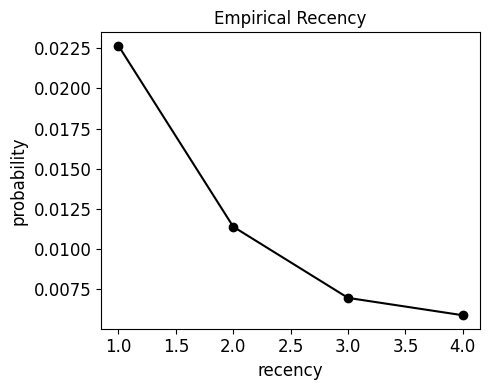

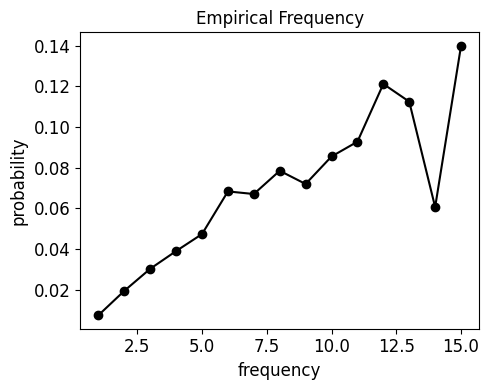

In [5]:
# emp: empirical product-choice probability (raw 2D table; contains sampling noise)
# er / ef: 1D empirical product-choice probability for recency / frequency respectively
fig_emp = scorer.plot_probability_surface(kind="emp")
fig_er = scorer.plot_marginal_probability(kind="er")
fig_ef = scorer.plot_marginal_probability(kind="ef")

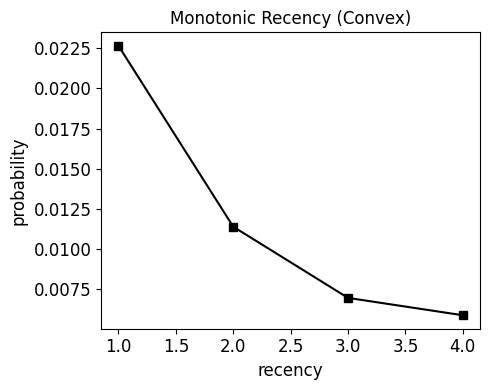

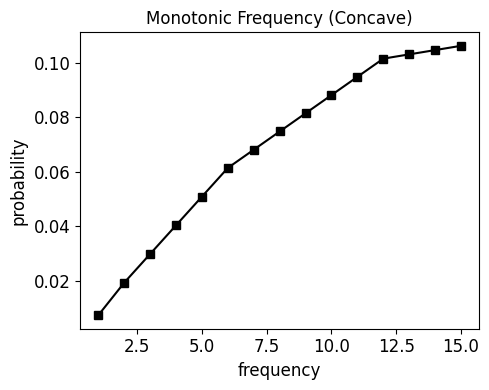

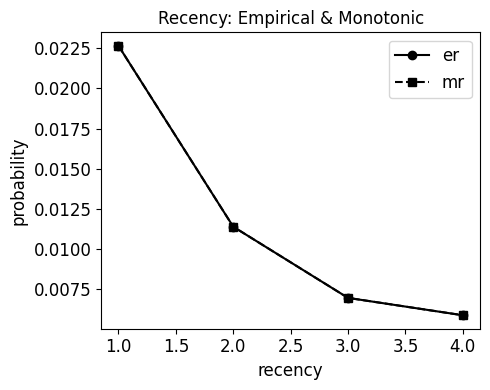

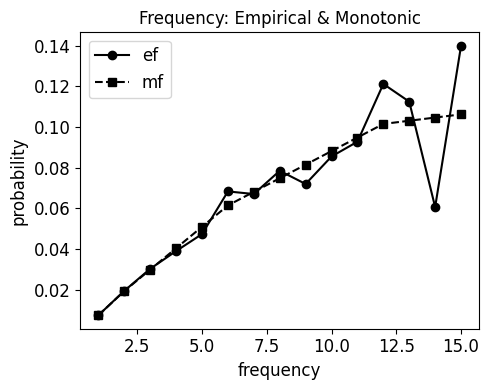

In [6]:
# mr / mf: 1D optimization models (mr = Recency monotonic decreasing + convexity, mf = Frequency monotonic increasing + concavity)
# rboth / fboth: overlay empirical vs optimized for comparison (confirm noise is removed and the curve becomes smooth)
scorer.optimize(kind="mr")
scorer.optimize(kind="mf")
fig_mr = scorer.plot_marginal_probability(kind="mr")
fig_mf = scorer.plot_marginal_probability(kind="mf")
fig_rboth = scorer.plot_marginal_probability(kind="rboth")
fig_fboth = scorer.plot_marginal_probability(kind="fboth")

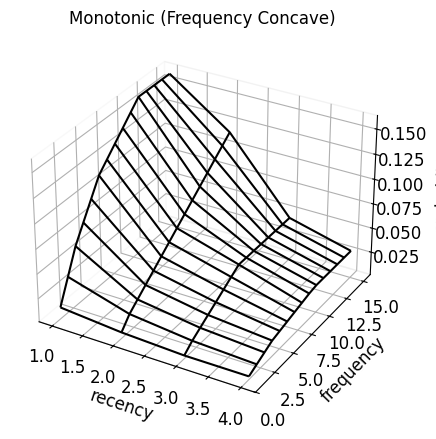

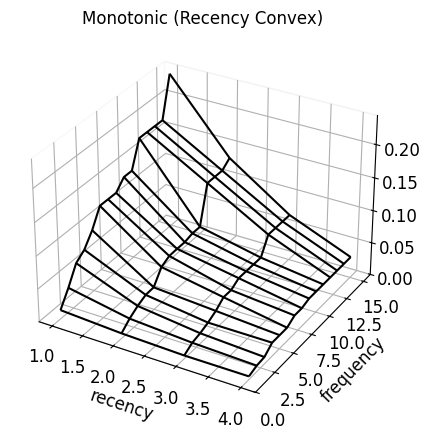

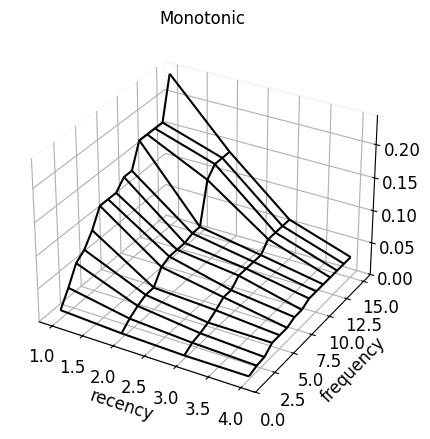

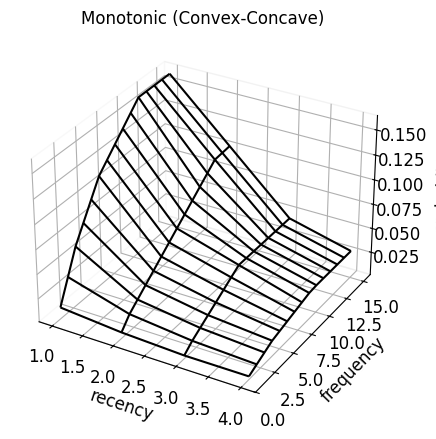

In [7]:
# 2D optimization models: mono (monotonicity only) / mrc (+Recency convexity) / mfc (+Frequency concavity) / mcc (+both)
scorer.optimize(kind="mono")
scorer.optimize(kind="mrc")
scorer.optimize(kind="mfc")
scorer.optimize(kind="mcc")

fig_mfc = scorer.plot_probability_surface(kind="mfc")
fig_mrc = scorer.plot_probability_surface(kind="mrc")
fig_mono = scorer.plot_probability_surface(kind="mono")
fig_mcc = scorer.plot_probability_surface(kind="mcc")

---
## **Generating and Evaluating Recommendations**

Attach every model's probabilities to the test data's observation data (`df_test_obs`) with `transform`,  
then compare against the ground truth data (`df_test_gt`) to evaluate recommendation accuracy with `evaluate`.

In [8]:
# Attach each model's product-choice probability and recommendation rank to the test data's observation data
# target_date: compute recency relative to the evaluation point (the operational "today")
kinds = ["er", "ef", "mr", "mf", "emp", "mono", "mrc", "mfc", "mcc"]
kind2df_rec = {kind: scorer.transform(df_test_obs, target_date, kind=kind) for kind in kinds}

In [9]:
# Aggregate and compare precision@1 across all models
# Performance is (mono = mrc > mfc = mcc > emp). The most strongly constrained mcc performs worse,
# suggesting the constraints may have been too strong (over-smoothing)
Rows = []
for kind, df_rec in kind2df_rec.items():
    top = scorer.evaluate(df_rec, df_test_gt, order=1).iloc[0]
    precision = top["precision"]
    recall = top["recall"]
    f1 = top["f1"]
    Rows.append((kind, precision, recall, f1))
df_eval = pd.DataFrame(Rows, columns=["kind", "precision", "recall", "f1"])
df_eval.sort_values("precision", ascending=False)

,kind,precision,recall,f1
5,mono,0.026734,0.016222,0.020192
6,mrc,0.026734,0.016222,0.020192
7,mfc,0.026679,0.016188,0.020150
8,mcc,0.026679,0.016188,0.020150
4,emp,0.026289,0.015952,0.019856
3,mf,0.025678,0.015581,0.019394
1,ef,0.025622,0.015548,0.019352
0,er,0.020287,0.012310,0.015322
2,mr,0.020287,0.012310,0.015322
